# An optimal first-order method for smooth and strongly convex composite optimization and its stationary limit

The following code uses [AutoLyap](https://autolyap.github.io/) [1] to validate the Prox-TMM rate from [2].

> [1] Manu Upadhyaya, Shuvomoy Das Gupta, Adrien B. Taylor, Sebastian Banert, and Pontus Giselsson.  
> "[The AutoLyap software suite for computer-assisted Lyapunov analyses of first-order methods](https://arxiv.org/abs/2506.24076)," arXiv:2506.24076, 2025.

> [2] Manu Upadhyaya, Daniel Berg Thomsen, Aymeric Dieuleveut, and Adrien B. Taylor.  
> "[An optimal first-order method for smooth and strongly convex composite optimization and its stationary limit](https://arxiv.org/abs/2605.22929)," arXiv:2605.22929, 2026.

## Authors

- [Manu Upadhyaya](https://manuupadhyaya.github.io/)
- [Daniel Berg Thomsen](https://bergthomsen.com/)
- [Aymeric Dieuleveut](http://www.cmap.polytechnique.fr/~aymeric.dieuleveut/)
- [Adrien Taylor](https://www.di.ens.fr/~ataylor/)

## Problem setup

Consider

$$
\underset{x \in \mathcal{H}}{\operatorname{minimize}}\; f(x)+g(x),
$$

where $\mathcal{H}$ is a real Hilbert space, $f \in \mathcal{F}_{\mu,L}(\mathcal{H})$ with $0<\mu<L$, and $g \in \mathcal{F}_{0,\infty}(\mathcal{H})$.

Initialize $q=\mu/L$ and $z^0=x^0$.

The Prox-TMM iteration is

$$
\begin{aligned}
y^k
&=\frac{2\sqrt{q}}{1+\sqrt{q}}z^k+\frac{1-\sqrt{q}}{1+\sqrt{q}}x^k,\\
\bar z^{k+1}
&=(1-\sqrt{q})z^k+\sqrt{q}\, y^k-\frac{1}{\sqrt{q}\,L}\nabla f(y^k),\\
z^{k+1}
&=\operatorname{Prox}^{1/(\sqrt{q}L)}_g(\bar z^{k+1}),\\
x^{k+1}
&=y^k-\frac{1}{L}\nabla f(y^k)-\sqrt{q}\,(\bar z^{k+1}-z^{k+1}).
\end{aligned}
$$

Using the proximal characterization, define the sampled subgradient

$$
s_g^{k+1}=\sqrt{q}L(\bar z^{k+1}-z^{k+1})\in \partial g(z^{k+1}).
$$

Then

$$
x^{k+1}=y^k-\frac{1}{L}\nabla f(y^k)-\frac{1}{L}s_g^{k+1}.
$$

In [6]:
%pip install -q autolyap matplotlib

import warnings

import matplotlib.pyplot as plt
import numpy as np

from autolyap import SolverOptions
from autolyap.algorithms import Algorithm
from autolyap.iteration_independent import IterationIndependent
from autolyap.problemclass import Convex, InclusionProblem, SmoothStronglyConvex

warnings.filterwarnings(
    "ignore",
    message="Solution may be inaccurate.*",
    category=UserWarning,
)

def mosek_fusion_is_available():
    try:
        import mosek
        import mosek.fusion  # noqa: F401
    except ImportError:
        return False

    try:
        env = mosek.Env()
    except Exception:
        return False

    checked_out = []
    try:
        for feature in (mosek.feature.pts, mosek.feature.pton):
            env.checkoutlicense(feature)
            checked_out.append(feature)
        return True
    except Exception:
        return False
    finally:
        for feature in reversed(checked_out):
            try:
                env.checkinlicense(feature)
            except Exception:
                pass


def get_solver_options():
    if mosek_fusion_is_available():
        return SolverOptions(backend="mosek_fusion")
    return SolverOptions(backend="cvxpy", cvxpy_solver="CLARABEL")


Note: you may need to restart the kernel to use updated packages.


## State-space representation

Match AutoLyap's [algorithm representation](https://autolyap.github.io/theory/algorithm_representation/) used by the [`Algorithm` API](https://autolyap.github.io/base_algorithms/):

$$
\begin{aligned}
\mathbf{x}^{k+1} &= (A\otimes \operatorname{Id})\mathbf{x}^k + (B\otimes \operatorname{Id})\mathbf{u}^k,\\
\mathbf{y}^k &= (C\otimes \operatorname{Id})\mathbf{x}^k + (D\otimes \operatorname{Id})\mathbf{u}^k,
\end{aligned}
$$

where we use

$$
\begin{aligned}
\mathbf{x}^k &= (x^k,z^k),\\
\mathbf{u}^k &= (\nabla f(y^k),s_g^{k+1}),\\
\mathbf{y}^k &= (y^k,z^{k+1}).
\end{aligned}
$$

Using $\mathbf{u}^k=(u_1^k,u_2^k)=(\nabla f(y^k),s_g^{k+1})$, the Prox-TMM update becomes

$$
\begin{aligned}
x^{k+1}
&=
\frac{1-\sqrt{q}}{1+\sqrt{q}}x^k
+
\frac{2\sqrt{q}}{1+\sqrt{q}}z^k
-\frac{1}{L}u_1^k
-\frac{1}{L}u_2^k,\\
z^{k+1}
&=
\frac{\sqrt{q}(1-\sqrt{q})}{1+\sqrt{q}}x^k
+
\left(1-\sqrt{q}+\frac{2q}{1+\sqrt{q}}\right)z^k
-\frac{1}{\sqrt{q}L}u_1^k
-\frac{1}{\sqrt{q}L}u_2^k,\\
y^k
&=
\frac{1-\sqrt{q}}{1+\sqrt{q}}x^k
+
\frac{2\sqrt{q}}{1+\sqrt{q}}z^k.
\end{aligned}
$$

Thus, the matrices are

$$
\begin{aligned}
A
&=
\begin{bmatrix}
\frac{1-\sqrt{q}}{1+\sqrt{q}}
&
\frac{2\sqrt{q}}{1+\sqrt{q}}\\
\frac{\sqrt{q}(1-\sqrt{q})}{1+\sqrt{q}}
&
1-\sqrt{q}+\frac{2q}{1+\sqrt{q}}
\end{bmatrix},
&
B
&=
\begin{bmatrix}
-\frac{1}{L} & -\frac{1}{L}\\
-\frac{1}{\sqrt{q}L} & -\frac{1}{\sqrt{q}L}
\end{bmatrix},\\
C
&=
\begin{bmatrix}
\frac{1-\sqrt{q}}{1+\sqrt{q}}
&
\frac{2\sqrt{q}}{1+\sqrt{q}}\\
\frac{\sqrt{q}(1-\sqrt{q})}{1+\sqrt{q}}
&
1-\sqrt{q}+\frac{2q}{1+\sqrt{q}}
\end{bmatrix},
&
D
&=
\begin{bmatrix}
0 & 0\\
-\frac{1}{\sqrt{q}L} & -\frac{1}{\sqrt{q}L}
\end{bmatrix}.
\end{aligned}
$$

In [7]:
class ProxTMM(Algorithm):
    def __init__(self, mu, L):
        super().__init__(n=2, m=2, m_bar_is=[1, 1], I_func=[1, 2], I_op=[])
        if not 0 < mu < L:
            raise ValueError("Require 0 < mu < L.")
        self.mu = mu
        self.L = L

    @property
    def rho_theory(self):
        return (1.0 - np.sqrt(self.mu / self.L)) ** 2

    def get_ABCD(self, k):
        return (
            np.array([
                [
                    (1.0 - np.sqrt(self.mu / self.L)) / (1.0 + np.sqrt(self.mu / self.L)),
                    2.0 * np.sqrt(self.mu / self.L) / (1.0 + np.sqrt(self.mu / self.L)),
                ],
                [
                    np.sqrt(self.mu / self.L) * (1.0 - np.sqrt(self.mu / self.L)) / (1.0 + np.sqrt(self.mu / self.L)),
                    1.0 - np.sqrt(self.mu / self.L) + 2.0 * self.mu / self.L / (1.0 + np.sqrt(self.mu / self.L)),
                ],
            ]),
            np.array([
                [-1.0 / self.L, -1.0 / self.L],
                [-1.0 / (np.sqrt(self.mu / self.L) * self.L), -1.0 / (np.sqrt(self.mu / self.L) * self.L)],
            ]),
            np.array([
                [
                    (1.0 - np.sqrt(self.mu / self.L)) / (1.0 + np.sqrt(self.mu / self.L)),
                    2.0 * np.sqrt(self.mu / self.L) / (1.0 + np.sqrt(self.mu / self.L)),
                ],
                [
                    np.sqrt(self.mu / self.L) * (1.0 - np.sqrt(self.mu / self.L)) / (1.0 + np.sqrt(self.mu / self.L)),
                    1.0 - np.sqrt(self.mu / self.L) + 2.0 * self.mu / self.L / (1.0 + np.sqrt(self.mu / self.L)),
                ],
            ]),
            np.array([
                [0.0, 0.0],
                [-1.0 / (np.sqrt(self.mu / self.L) * self.L), -1.0 / (np.sqrt(self.mu / self.L) * self.L)],
            ]),
        )


## AutoLyap Lyapunov sweep

We sweep over $50$ values of $q=\mu/L$ in the open interval $(0,1)$ and plot the contraction factor. 

Following AutoLyap's [iteration-independent analysis](https://autolyap.github.io/theory/iteration_independent_analyses/) ([API](https://autolyap.github.io/iteration_independent_analysis/)), the search looks for variables $Q,q$ satisfying

$$
\mathcal{V}(Q,q,k+1)
\le
\rho\,\mathcal{V}(Q,q,k),
\tag{C1}
$$

$$
\mathcal{V}(Q,q,k)\ge \|z^{k+1}-x^\star\|^2.
\tag{C2}
$$

By induction,

$$
\|z^{k+1}-x^\star\|^2\le\rho^k\mathcal{V}(Q,q,0).
$$

and hence

$$
\|z^{k}-x^\star\|^2\in\mathcal{O}(\rho^k)
\quad\text{as}\quad k\to\infty.
$$

The paper gives the rate

$$
\|z^k-x^\star\|^2\in\mathcal{O}\!\left(\rho_\mathrm{theory}^k\right)
\quad\text{as}\quad k\to\infty,
$$

where

$$
\rho_\mathrm{theory}=(1-\sqrt{q})^2=(1-\sqrt{\mu/L})^2.
$$

In [8]:
# 50 values in the open interval (0, 1).
q_values = np.linspace(0.0, 1.0, 52)[1:-1]
L_sweep = 1.0
solver_options = get_solver_options()

rho_autolyap_values = []
rho_theory_values = []

for idx, q_value in enumerate(q_values, start=1):
    mu_value = float(q_value * L_sweep)
    sweep_problem = InclusionProblem([
        SmoothStronglyConvex(mu_value, L_sweep),
        Convex(),
    ])
    sweep_algorithm = ProxTMM(mu=mu_value, L=L_sweep)
    P_sweep, p_sweep, T_sweep, t_sweep = (
        IterationIndependent.LinearConvergence.get_parameters_distance_to_solution(
            sweep_algorithm,
            i=2,
            j=1,
        )
    )
    result = IterationIndependent.LinearConvergence.bisection_search_rho(
        sweep_problem,
        sweep_algorithm,
        P_sweep,
        T_sweep,
        p=p_sweep,
        t=t_sweep,
        S_equals_T=True,
        s_equals_t=True,
        remove_C3=True,
        solver_options=solver_options,
        verbosity=0,
    )
    if result["status"] != "feasible":
        raise RuntimeError(f"No feasible certificate for q={q_value:.6f}.")

    rho_autolyap_values.append(float(result["rho"]))
    rho_theory_values.append(sweep_algorithm.rho_theory)
    print(f"Solved {idx:>2}/{len(q_values)}: q={q_value:.3f}")

rho_autolyap_values = np.array(rho_autolyap_values)
rho_theory_values = np.array(rho_theory_values)


Solved  1/50: q=0.020
Solved  2/50: q=0.039
Solved  3/50: q=0.059
Solved  4/50: q=0.078
Solved  5/50: q=0.098
Solved  6/50: q=0.118
Solved  7/50: q=0.137
Solved  8/50: q=0.157
Solved  9/50: q=0.176
Solved 10/50: q=0.196
Solved 11/50: q=0.216
Solved 12/50: q=0.235
Solved 13/50: q=0.255
Solved 14/50: q=0.275
Solved 15/50: q=0.294
Solved 16/50: q=0.314
Solved 17/50: q=0.333
Solved 18/50: q=0.353
Solved 19/50: q=0.373
Solved 20/50: q=0.392
Solved 21/50: q=0.412
Solved 22/50: q=0.431
Solved 23/50: q=0.451
Solved 24/50: q=0.471
Solved 25/50: q=0.490
Solved 26/50: q=0.510
Solved 27/50: q=0.529
Solved 28/50: q=0.549
Solved 29/50: q=0.569
Solved 30/50: q=0.588
Solved 31/50: q=0.608
Solved 32/50: q=0.627
Solved 33/50: q=0.647
Solved 34/50: q=0.667
Solved 35/50: q=0.686
Solved 36/50: q=0.706
Solved 37/50: q=0.725
Solved 38/50: q=0.745
Solved 39/50: q=0.765
Solved 40/50: q=0.784
Solved 41/50: q=0.804
Solved 42/50: q=0.824
Solved 43/50: q=0.843
Solved 44/50: q=0.863
Solved 45/50: q=0.882
Solved 46/

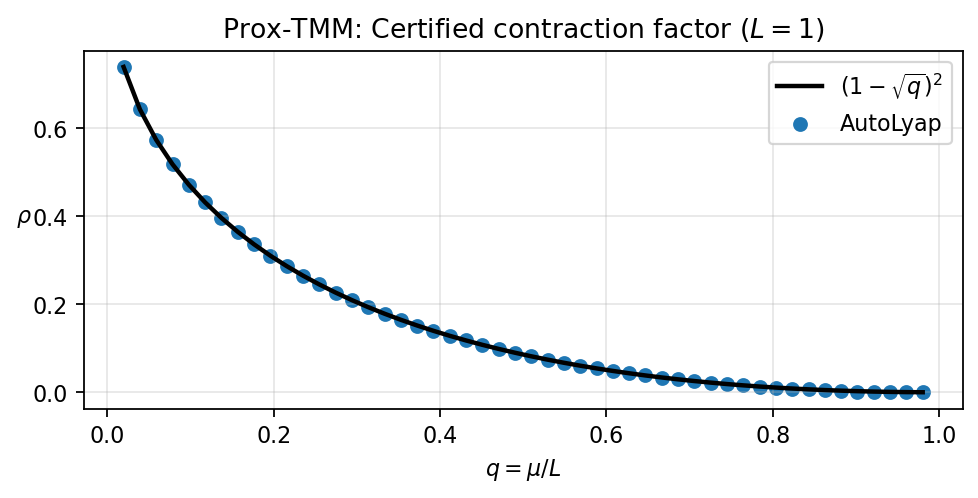

In [9]:
fig, ax = plt.subplots(figsize=(6, 3), dpi=160, constrained_layout=True)
ax.plot(q_values, rho_theory_values, color="black", linewidth=2.0, label="$(1-\\sqrt{q})^2$")
ax.scatter(q_values, rho_autolyap_values, s=32, color="#1f77b4", label="AutoLyap")
ax.set_xlabel("$q=\\mu/L$")
ax.set_ylabel("$\\rho$", rotation=0)
ax.set_title(rf"Prox-TMM: Certified contraction factor ($L={L_sweep:g}$)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()
